# Check Baysor output for duplicate transcript assignments

Based on direct Baysor output from single sopa patch (kept using --keep_cache). Also see https://kharchenkolab.github.io/Baysor/dev/segmentation/#Outputs.

Opened issue: https://github.com/gustaveroussy/sopa/issues/397

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from matplotlib.collections import PatchCollection

from cellseg_benchmark._constants import BASE_PATH
from spatialdata import read_zarr

/home/ubuntu/miniforge3/envs/seg_postprocessing/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


## load baysor output

In [138]:
patch = 35

sample_path = Path(BASE_PATH) / "samples/aging_s8_r1"
patches_dir = (
    sample_path
    / "results/Baysor_2D_Cellpose_2_DAPI_PolyT_0.2/sdata.zarr/.sopa_cache/transcript_patches"
)
cell_stats = pd.read_csv(patches_dir / str(patch) / "segmentation_cell_stats.csv")
molecule_stats = pd.read_csv(patches_dir / str(patch) / "segmentation.csv")
with open(patches_dir / str(patch) / "segmentation_polygons_2d.json") as f:
    polygon_data = json.load(f)

In [186]:
molecule_stats.head()

,x,y,gene,transcript_id,Unnamed: 0,barcode_id,fov,cell_id,sopa_prior,molecule_id,prior_segmentation,confidence,cluster,cell,assignment_confidence,is_noise,ncv_color
0,8831.959,8793.568,Gclm,ENSMUST00000149983,7,427,794,-1,41723,1,619,0.98474,7,CRbd40c4ac5-2721,1.00,False,#00B97F
1,8866.908,8806.562,Gclm,ENSMUST00000149983,17,427,794,-1,0,2,0,0.99949,3,CRbd40c4ac5-2779,0.96,False,#00AAFF
2,8819.093,8814.934,Gclm,ENSMUST00000149983,23,427,794,1364935900121100388,41759,3,654,0.99946,7,CRbd40c4ac5-2741,0.94,False,#B7AA51
3,8816.638,8816.233,Gclm,ENSMUST00000149983,24,427,794,1364935900121100388,41759,4,654,0.99940,4,CRbd40c4ac5-2741,1.00,False,#B3A200
4,8803.716,8816.203,Gclm,ENSMUST00000149983,25,427,794,1364935900121100387,41757,5,652,0.99929,4,CRbd40c4ac5-2718,1.00,False,#CAA9B1


## plot boundaries

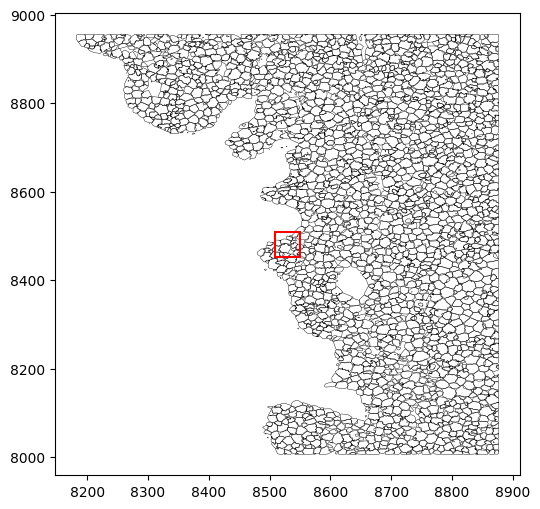

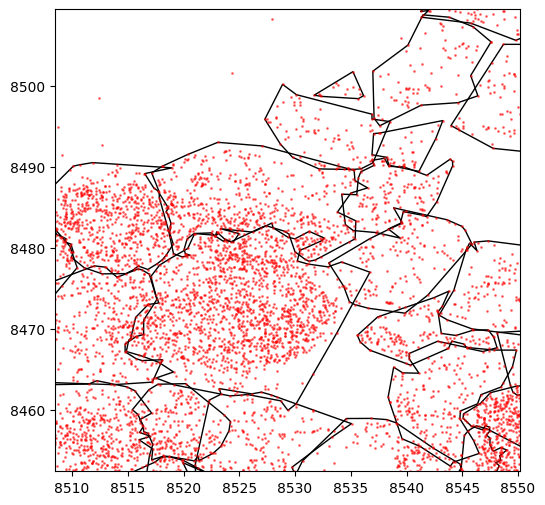

In [140]:
polys = (
    [g["coordinates"][0] for g in polygon_data["geometries"]]
    if polygon_data["type"] == "GeometryCollection"
    else [f["geometry"]["coordinates"][0] for f in polygon_data["features"]]
)

all_pts = np.concatenate([np.array(p) for p in polys])
xmin, ymin = all_pts.min(axis=0)
xmax, ymax = all_pts.max(axis=0)
cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
w, h = (xmax - xmin) * 0.06, (ymax - ymin) * 0.06
x0, x1, y0, y1 = cx - w / 2, cx + w / 2, cy - h / 2, cy + h / 2

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(
    PatchCollection(
        [Polygon(p) for p in polys], facecolor="none", edgecolor="black", linewidth=0.3
    )
)
ax.autoscale()
ax.add_patch(
    Rectangle((x0, y0), w, h, linewidth=1.5, edgecolor="red", facecolor="none")
)
plt.show()

zoom = molecule_stats[
    molecule_stats.x.between(x0, x1) & molecule_stats.y.between(y0, y1)
]
fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(
    PatchCollection(
        [Polygon(p) for p in polys], facecolor="none", edgecolor="black", linewidth=1
    )
)
ax.scatter(zoom.x, zoom.y, s=1, c="red", alpha=0.5)
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
plt.show()

In [189]:
from shapely.geometry import Polygon as ShapelyPolygon

shapes = gpd.GeoDataFrame(geometry=[ShapelyPolygon(np.array(p)[:, :2]) for p in polys])
# find any truly overlapping pairs
from shapely.ops import unary_union

overlaps = []
for i, g1 in shapes.iterrows():
    for j, g2 in shapes.iterrows():
        if i >= j:
            continue
        if g1.geometry.intersects(g2.geometry):
            overlaps.append((i, j))
print(len(overlaps))

5001


In [141]:
x0, x1, y0, y1

(np.float64(8508.46719),
 np.float64(8550.17181),
 np.float64(8452.473075),
 np.float64(8509.432425))

## compute assigned transcripts

In [5]:
total_transcripts = len(molecule_stats)
assigned = molecule_stats[molecule_stats["cell"] != ""]
noise = molecule_stats[molecule_stats["is_noise"] == True]
print(f"Total transcripts in segmentation.csv:       {total_transcripts}")
print(f"Noise (is_noise == True):                    {len(noise)}")
print(
    f"Sum of n_transcripts from cell_stats:        {cell_stats['n_transcripts'].sum()}"
)
print(
    f"Fraction assigned in cell_stats:             {cell_stats['n_transcripts'].sum() / total_transcripts:.4f}"
)

Total transcripts in segmentation.csv:       2531587
Noise (is_noise == True):                    389
Sum of n_transcripts from cell_stats:        2531198
Fraction assigned in cell_stats:             0.9998


Verify: Sum of n_transcripts from cell_stats metadata is concistent with counts from cell by gene matrix

In [6]:
# import sys
#!mamba install bioconda::loompy -y --prefix {sys.prefix}

In [7]:
# import loompy
# with loompy.connect(sample_path / "results/Baysor_2D_Cellpose_2_DAPI_PolyT_0.2/sdata.zarr/.sopa_cache/transcript_patches" / str(patch) / "segmentation_counts.loom", validate=False) as ds:
#    loom_total = ds[:, :].sum()
# loom_total == cell_stats['n_transcripts'].sum()
# is consistent (y)

In [8]:
# Check for possible duplicate transcript assignments (same "transcript_id", "x", "y")
dupes = assigned.duplicated(subset=["transcript_id", "x", "y"], keep=False)
print(
    f'Transcripts with overlapping ["transcript_id", "x", "y"]:       {dupes.sum()} ({dupes.mean() * 100:.2f}%)'
)

Transcripts with overlapping ["transcript_id", "x", "y"]:       1261 (0.05%)


In [9]:
assigned[dupes].sort_values("transcript_id").head(4)

,x,y,gene,transcript_id,Unnamed: 0,barcode_id,fov,cell_id,sopa_prior,molecule_id,prior_segmentation,confidence,cluster,cell,assignment_confidence,is_noise,ncv_color
2290523,9572.183,6390.1797,Sox9,ENSMUST00000000579,11,4,861,1364935900063100583,20525,2290524,549,1.0,10,CR27f0f0479-3395,1.0,False,#00D0FF
2312645,9572.183,6390.1797,Sox9,ENSMUST00000000579,6,4,861,1364935900063100583,20525,2312646,549,1.0,10,CR27f0f0479-3395,1.0,False,#00D0FF
707000,9247.876,7093.9097,Epn2,ENSMUST00000001063,202,7,829,1364935900086100152,21928,707001,1765,1.0,2,CR27f0f0479-5216,1.0,False,#0097FF
718201,9247.876,7093.9097,Epn2,ENSMUST00000001063,207,7,829,1364935900086100152,21928,718202,1765,1.0,2,CR27f0f0479-5216,1.0,False,#0097FF


Note: These could derive from the same x/y position of different z planes, not necessarily duplicates.

In [10]:
transcript_id, transcript_x, transcript_y = (
    assigned[dupes].sort_values("transcript_id")[["transcript_id", "x", "y"]].iloc[0]
)
transcript_id, transcript_x, transcript_y

('ENSMUST00000000579', np.float64(9572.183), np.float64(6390.1797))

In [11]:
# load original points table
points_df = read_zarr(sample_path / "sdata_z3.zarr")[
    "aging_s8_r1_transcripts"
].compute()

version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/ubuntu/miniforge3/envs/seg_postprocessing/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/ubuntu/miniforge3/envs/seg_postprocessing/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/ubuntu/miniforge3/envs/seg_postprocessing/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/ubuntu/miniforge3/envs/seg_postprocessing/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/ubuntu/miniforge3/envs/seg_postp

In [12]:
points_df[
    (points_df["transcript_id"] == transcript_id)
    & (points_df["x"] == transcript_x)
    & (points_df["y"] == transcript_y)
]

,x,y,gene,global_z,cell_id,fov,Unnamed: 0,transcript_id,barcode_id
167575,9572.183,6390.1797,Sox9,2.0,1364935900063100583,861,11,ENSMUST00000000579,4
189819,9572.183,6390.1797,Sox9,3.0,1364935900063100583,861,6,ENSMUST00000000579,4


In [13]:
del points_df

Confirmed: transcripts with overlapping id/x/y are from separate z planes.

Hence, no duplicate assignments in baysor output.

## loop through patches

confirm no overlap across all patches

In [14]:
for patch_dir in sorted(patches_dir.iterdir()):
    csv = patch_dir / "segmentation.csv"
    stats = patch_dir / "segmentation_cell_stats.csv"
    if not (csv.exists() and stats.exists()):
        continue
    mol = pd.read_csv(csv)
    assigned_frac = (pd.read_csv(stats)["n_transcripts"].sum()) / len(mol)
    print(f"Patch {patch_dir.name}: {assigned_frac:.4f}")

Patch 10: 0.9994
Patch 11: 0.9992
Patch 12: 0.9980
Patch 14: 0.9851
Patch 15: 0.9982
Patch 16: 0.9965
Patch 17: 0.9996
Patch 18: 0.9997
Patch 19: 0.9994
Patch 2: 0.9972
Patch 20: 0.9959
Patch 21: 0.9980
Patch 22: 0.9998
Patch 23: 0.9999
Patch 24: 0.9999
Patch 25: 0.9998
Patch 26: 0.9991
Patch 27: 0.9963
Patch 28: 0.9988
Patch 29: 0.9994
Patch 3: 0.9981
Patch 30: 1.0000
Patch 31: 0.9999
Patch 32: 0.9994
Patch 33: 0.9999
Patch 34: 0.9981
Patch 35: 0.9978
Patch 36: 0.9999
Patch 37: 0.9999
Patch 38: 0.9999
Patch 39: 0.9997
Patch 4: 0.9962
Patch 40: 0.9765
Patch 41: 0.9964
Patch 42: 0.9987
Patch 43: 0.9992
Patch 44: 0.9850
Patch 45: 0.9582
Patch 46: 0.9467
Patch 47: 0.9993
Patch 48: 0.8275
Patch 50: 0.9668
Patch 51: 0.9986
Patch 52: 0.9992
Patch 53: 0.9988
Patch 54: 0.9796
Patch 8: 0.9858
Patch 9: 0.9996


## load baysor output after sopa formatting

Including all patches

In [155]:
sdata_path = sample_path / "results/Baysor_2D_Cellpose_2_DAPI_PolyT_0.2/sdata.zarr"

In [156]:
sdata = read_zarr(sdata_path)

In [180]:
# noqa: F401
import spatialdata as sd
import spatialdata_plot

In [158]:
for key in sdata.shapes:
    transforms = sd.transformations.get_transformation(sdata.shapes[key], get_all=True)
    print(key, transforms)

baysor_boundaries {'global': Affine (x, y -> x, y)
    [ 9.25935650e+00  0.00000000e+00 -7.39286562e+04]
    [ 0.00000000e+00  9.25934982e+00 -3.09820449e+04]
    [0. 0. 1.]}
cellpose_boundaries {'global': Identity }
image_patches {'global': Identity }
transcripts_patches {'global': Affine (x, y -> x, y)
    [ 9.25935650e+00  0.00000000e+00 -7.39286562e+04]
    [ 0.00000000e+00  9.25934982e+00 -3.09820449e+04]
    [0. 0. 1.]}


- Global = pixel
- baysor_boundaries and transcripts_patches  are in microns

In [164]:
x0, x1, y0, y1

(np.float64(8508.46719),
 np.float64(8550.17181),
 np.float64(8452.473075),
 np.float64(8509.432425))

In [171]:
# transform boudnary box from microns to pixel
t = sd.transformations.get_transformation(sdata.shapes["baysor_boundaries"], "global")
A = t.matrix


def transform(x, y):
    v = A @ np.array([x, y, 1.0])
    return v[0], v[1]


x0_px, y0_px = transform(x0, y0)
x1_px, y1_px = transform(x1, y1)

In [172]:
sdata_crop = sdata.query.bounding_box(
    axes=("x", "y"),
    min_coordinate=[x0_px, y0_px],
    max_coordinate=[x1_px, y1_px],
    target_coordinate_system="global",
)

In [173]:
sdata_crop

SpatialData object
├── Shapes
│     ├── 'baysor_boundaries': GeoDataFrame shape: (24, 1) (2D shapes)
│     ├── 'cellpose_boundaries': GeoDataFrame shape: (10, 1) (2D shapes)
│     ├── 'image_patches': GeoDataFrame shape: (1, 3) (2D shapes)
│     └── 'transcripts_patches': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      └── 'table': AnnData (24, 499)
with coordinate systems:
    ▸ 'global', with elements:
        baysor_boundaries (Shapes), cellpose_boundaries (Shapes), image_patches (Shapes), transcripts_patches (Shapes)

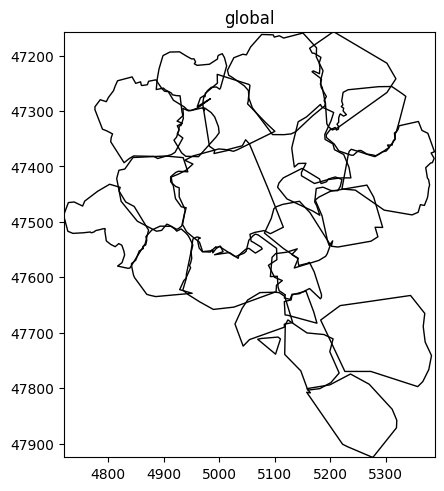

In [194]:
sdata_crop.pl.render_shapes(
    element="baysor_boundaries", fill_alpha=0, outline_width=1
).pl.show(coordinate_systems="global")

no change: boundaries also overlapping